# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 02 — Arquitectura downstream y baselines no generativos

**Objetivo.** Antes de generar un solo dato sintético, este notebook fija dos cosas que el
resto del taller tratará como constantes:

1. **El suelo del experimento**: tres baselines clásicos sin redes (media global,
   persistencia de la volatilidad realizada, HAR-RV lineal). Cualquier red — y cualquier
   mezcla real+sintético — tendrá que justificarse frente a ellos.
2. **La arquitectura downstream congelada**: el enunciado exige buscar una arquitectura
   válida con datos reales y reutilizarla *idéntica* en todas las mezclas real/sintético.
   Aquí se hace esa búsqueda, se elige campeona por validación (real), se cuantifica su
   ruido de optimización con varias semillas y se persiste su configuración y sus pesos.

**Regla de congelación.** A partir de este notebook, ni la arquitectura ni los
hiperparámetros de entrenamiento cambian: si una celda de la malla real×sintético rinde
distinto, la única explicación posible serán los datos. Ese es el diseño experimental.

> Módulos: `src/baselines.py` (predictores clásicos y métricas), `src/models.py`
> (arquitecturas candidatas), `src/training.py` (harness único de entrenamiento con
> early stopping sobre validación real).

## 0 · Setup y contrato de datos

Consumimos exclusivamente los artefactos del notebook 01. La estandarización usa los
estadísticos congelados de train (`standardizer.json`); el test no interviene en ninguna
decisión de este notebook — solo se informa al final, como referencia.

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.baselines import predict_global_mean, predict_persistence, HarOLS, regression_metrics
from src.models import build_model, count_params
from src.training import train_model, predict, get_device
from src.eda import PALETTE, _style

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
if device.type == "cpu":
    torch.set_num_threads(8)
print("Device:", device)

d = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))
X = {s: d[f"X_{s}"] for s in ("train", "val", "test")}
y = {s: d[f"y_{s}"] for s in ("train", "val", "test")}

# Versiones estandarizadas (entrada de las redes). Los baselines usan X crudo:
# calculan volatilidades realizadas en unidades físicas.
Xs = {s: (X[s] - std["x_mu"]) / std["x_sd"] for s in X}
ys = {s: (y[s] - std["y_mu"]) / std["y_sd"] for s in y}
{s: X[s].shape for s in X}

C:\Users\diego\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Device: cuda


{'train': (102406, 60), 'val': (17146, 60), 'test': (24613, 60)}

## 1 · Protocolo de evaluación

* **Métricas**: MSE, MAE y R² en el espacio del target, `y = ln σ_anualizada`. El R² se
  calcula contra la varianza del target *dentro de cada partición* — con distribution
  shift entre particiones (documentado en el 01) es la única comparación honesta.
* **Selección**: todas las decisiones (arquitectura, época de la que se conservan los
  pesos) se toman con **validación real**. El test se informa una única vez por modelo, como referencia, y no
  alimenta ninguna decisión.
* **Ruido de optimización**: la campeona se reentrena con 3 semillas; la dispersión entre
  semillas es la vara de medir para saber si una diferencia futura entre mezclas
  real/sintético es señal o ruido.

## 2 · Baselines no generativos

| Baseline | Qué explota | Por qué está aquí |
|---|---|---|
| Media global de train | nada (constante) | detecta el shift de nivel entre particiones |
| Persistencia RV-21 | la persistencia de σ | el heurístico del practicante: "la vol que viene será como la que hubo" |
| HAR-RV (OLS) | RV a 1/5/21/60 días | el estándar de la literatura (Corsi, 2009); lineal y sin hiperparámetros |

In [2]:
har = HarOLS().fit(X["train"], y["train"])

baseline_preds = {
    "media_global": {s: predict_global_mean(y["train"], len(y[s])) for s in ("val", "test")},
    "persistencia_rv21": {s: predict_persistence(X[s]) for s in ("val", "test")},
    "har_ols": {s: har.predict(X[s]) for s in ("val", "test")},
}

rows = []
for name, preds in baseline_preds.items():
    for s in ("val", "test"):
        rows.append({"modelo": name, "particion": s, **regression_metrics(y[s], preds[s])})
tabla_baselines = pd.DataFrame(rows).set_index(["modelo", "particion"]).round(4)
print("Coeficientes HAR [const, lnRV1, lnRV5, lnRV21, lnRV60]:", np.round(har.coef_, 3))
tabla_baselines

Coeficientes HAR [const, lnRV1, lnRV5, lnRV21, lnRV60]: [-0.366  0.006  0.178  0.159  0.39 ]


mse     mae      r2
modelo            particion                        
media_global      val        0.2269  0.3657 -0.1800
                  test       0.2668  0.3932 -0.1446
persistencia_rv21 val        0.1563  0.2997  0.1871
                  test       0.2052  0.3448  0.1199
har_ols           val        0.1136  0.2526  0.4090
                  test       0.1495  0.2910  0.3586

**Lectura crítica.** Tres observaciones que condicionan todo lo que sigue:

1. **La media global tiene R² negativo en val y test.** No es un error: es el
   distribution shift del notebook 01 haciéndose visible — la media de train (anclada en
   la calma 2012–2019) queda sistemáticamente por debajo del nivel de σ de 2022–2026.
   Cualquier modelo que aprenda *algo* de la ventana lo supera de largo.
2. **La persistencia ya captura una parte de la señal** con cero parámetros: la
   persistencia de σ es real y explotable.
3. **HAR-RV es el listón serio** (R² ≈ 0,36 en test con 5 coeficientes). La distancia
   entre HAR y la mejor red medirá cuánta no-linealidad adicional hay que extraer de la
   ventana; la experiencia de la literatura es que esa distancia es real pero modesta.
   Si una red no bate a HAR, la red sobra — y lo mismo valdrá para los datos sintéticos.

## 3 · Búsqueda de arquitectura (con datos reales)

Seis candidatas pequeñas: tres familias (MLP, CNN 1-D y GRU) en **dos tamaños cada
una**, de ~15k a ~85k parámetros. El diseño pareado importa: comparar familias con una
sola talla por familia confunde "esta familia es mejor" con "esta red tenía el tamaño
adecuado". Con dos tallas se ve si la familia gana por su sesgo inductivo o por
capacidad. Las dos primeras familias son invariantes al orden en distinto grado; la
GRU es el contraste secuencial, la única que puede representar dependencias de largo
alcance dentro de la ventana. Si el orden de los retornos lleva señal más allá de su
magnitud, aquí es donde tiene que aparecer.
Pequeñas a propósito: el objeto del taller es medir el efecto de los *datos*, y la malla
posterior requiere cientos de entrenamientos — un modelo grande añadiría varianza de
optimización y coste sin cambiar la pregunta. Mismo harness, mismos hiperparámetros de
entrenamiento, misma semilla: la comparación es entre arquitecturas, no entre recetas.

> **Receta de entrenamiento — dos elementos que no son cosméticos.** El target
> estandarizado tiene colas de hasta |z| ≈ 7,7 y las entradas hasta |z| ≈ 30. Con MSE, un
> lote que contenga una de esas muestras aporta una pérdida ~50 frente a la típica ~0,4:
> un pico de gradiente de dos órdenes de magnitud. Sin tratarlo, las curvas de validación
> salen con dientes de sierra y **no demuestran convergencia** — justo lo que el enunciado
> exige demostrar. La solución correcta es **recortar la norma del gradiente**
> (`grad_clip=1.0`), que acota el tamaño del paso sin tocar el objetivo; winsorizar el
> target lo habría "arreglado" cambiando el problema, inadmisible en un taller cuyo objeto
> son precisamente las colas. Añadimos además **cosine annealing** del learning rate y
> entrenamos el horizonte completo (sin parada temprana, `patience = epochs`), quedándonos
> con los mejores pesos: así la última parte de cada curva refina en lugar de rebotar y la
> convergencia es inequívoca a simple vista.

In [3]:
CANDIDATAS = {
    "mlp_s":  ("mlp", {"hidden": (128, 64)}),
    "mlp_l":  ("mlp", {"hidden": (256, 128, 64)}),
    "cnn_s":  ("cnn", {"channels": (32, 64)}),
    "cnn_l":  ("cnn", {"channels": (32, 64, 128), "fc": 128}),
    "gru_s":  ("gru", {}),                                      # 2 capas h=64, 42k
    "gru_l":  ("gru", {"hidden": 72, "layers": 3, "fc": 72}),   # 3 capas h=72, 85k
}
# 100 y no 40: con cosine annealing el horizonte ES el schedule del learning rate,
# asi que alargarlo no es "entrenar mas" sino refinar mas fino al final. Medido
# sobre las seis candidatas, subir de 40 a 150 epocas NO mejora el MSE de
# validacion (los CNN incluso empeoran una milesima, las GRU empatan): lo que
# compra es la MESETA, que pasa de max/min ~1,012 a ~1,001 en las ultimas 10
# epocas. Es decir, compra el requisito de convergencia del enunciado, no
# precision. 100 captura casi toda esa mejora; 150 cuesta un 50% mas y la malla
# del nb04 hereda esta receta celda a celda, asi que el horizonte se paga 333
# veces alli.
EPOCHS = 100
TRAIN_KW = dict(epochs=EPOCHS, batch_size=1024, lr=1e-3, weight_decay=1e-5,
                patience=EPOCHS, grad_clip=1.0, cosine=True)

resultados = {}
for name, (arch, kw) in CANDIDATAS.items():
    model = build_model(arch, **kw)
    res = train_model(model, Xs["train"], ys["train"], Xs["val"], ys["val"],
                      seed=cfg.seed, device=device, **TRAIN_KW)
    # métricas en el espacio físico ln σ (des-estandarizando la predicción)
    pv = predict(model, Xs["val"], device) * std["y_sd"] + std["y_mu"]
    resultados[name] = {"model": model, "res": res,
                        "val": regression_metrics(y["val"], pv),
                        "params": count_params(model)}
    print(f"{name:6s} | {resultados[name]['params']:>7,} params | "
          f"mejor época {res.best_epoch:3d} | val MSE {resultados[name]['val']['mse']:.4f} | "
          f"{res.seconds:.0f}s")

mlp_s  |  16,129 params | mejor época  64 | val MSE 0.1104 | 22s


mlp_l  |  56,833 params | mejor época  17 | val MSE 0.1141 | 22s


cnn_s  |  14,721 params | mejor época  19 | val MSE 0.0945 | 29s


cnn_l  |  68,225 params | mejor época   5 | val MSE 0.0946 | 38s


gru_s  |  42,049 params | mejor época   9 | val MSE 0.0915 | 91s


gru_l  |  84,601 params | mejor época  16 | val MSE 0.0917 | 196s


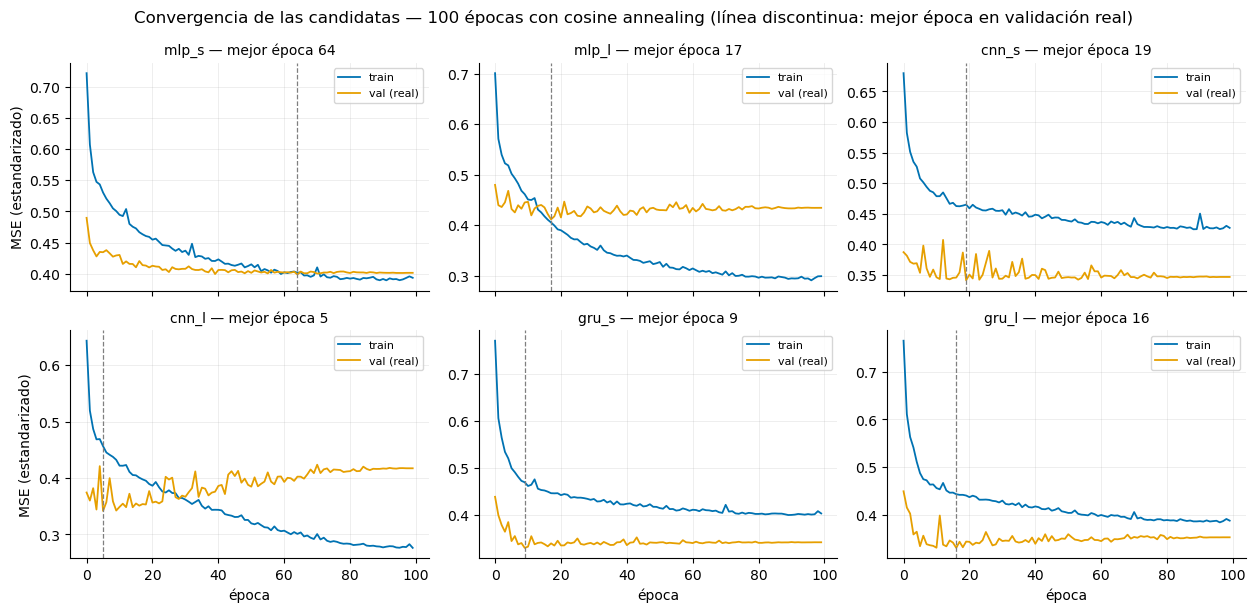

In [4]:
# Curvas de loss: el requisito de convergencia del enunciado, para cada candidata
# La rejilla se deriva del numero de candidatas: anadir una mas no obliga a
# retocar la figura (con 2x2 cableado, la quinta se perdia en silencio).
NCOLS = 3
nrows = int(np.ceil(len(resultados) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(4.2 * NCOLS, 3.1 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, (name, r) in zip(axes, resultados.items()):
    h = r["res"]
    ax.plot(h.train_loss, color=PALETTE["blue"], lw=1.3, label="train")
    ax.plot(h.val_loss, color=PALETTE["orange"], lw=1.3, label="val (real)")
    ax.axvline(h.best_epoch, color=PALETTE["grey"], ls="--", lw=0.9)
    ax.set_title(f"{name} — mejor época {h.best_epoch}", fontsize=10)
    ax.legend(fontsize=8)
    _style(ax)
for ax in axes[len(resultados):]:              # huecos si la rejilla no cuadra
    ax.set_visible(False)
for k, ax in enumerate(axes[:len(resultados)]):
    if k % NCOLS == 0:
        ax.set_ylabel("MSE (estandarizado)")   # solo la columna izquierda
    if k + NCOLS >= len(resultados):           # ultimo visible de su columna:
        ax.set_xlabel("época")                 # sharex le habria ocultado los ticks
        ax.tick_params(labelbottom=True)
fig.suptitle(f"Convergencia de las candidatas — {EPOCHS} épocas con cosine annealing "
             "(línea discontinua: mejor época en validación real)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "09_convergencia_candidatas.png", dpi=120, bbox_inches="tight")

**Prueba numérica de convergencia.** "Se ve plana" no es un criterio. Medimos, sobre las
**últimas 10 épocas** de cada curva de validación, el cociente máximo/mínimo (cercano a 1
= meseta) y la pendiente de una recta ajustada (cercana a 0 = sin tendencia residual, ni
de mejora ni de degradación). Es la evidencia que respalda la afirmación de convergencia
que exige el enunciado.

In [5]:
conv = []
for name, r in resultados.items():
    v = np.array(r["res"].val_loss)[-10:]
    conv.append({"modelo": name,
                 "val_max/min_ult10": v.max() / v.min(),
                 "pendiente_ult10": np.polyfit(np.arange(len(v)), v, 1)[0],
                 "val_final": v[-1]})
pd.DataFrame(conv).set_index("modelo").round(4)

,val_max/min_ult10,pendiente_ult10,val_final
modelo,,,
mlp_s,1.0012,-0.0000,0.4014
mlp_l,1.0037,0.0001,0.4348
cnn_s,1.0033,-0.0001,0.3468
cnn_l,1.0032,0.0000,0.4173
gru_s,1.0021,-0.0000,0.3422
gru_l,1.0055,-0.0001,0.3533


## 4 · Selección, ruido de optimización y congelación

Elegimos la arquitectura por MSE de validación y la reentrenamos 3 veces con la misma
receta, cambiando solo la semilla aleatoria (inicialización de pesos y orden de batches).
La dispersión (std) entre esas 3 corridas es ruido puro de optimización — la vara de
medir: una mejora futura por datos sintéticos solo será creíble si la supera. Los pesos
que se persisten son los de la semilla **mediana** en val MSE, no la mejor, para no
quedarnos con una corrida afortunada.

In [6]:
champion_name = min(resultados, key=lambda k: resultados[k]["val"]["mse"])
arch, kw = CANDIDATAS[champion_name]
print(f"Campeona por validación: {champion_name}  ({arch}, {kw})")

runs = []
for seed in (42, 43, 44):
    m = build_model(arch, **kw)
    r = train_model(m, Xs["train"], ys["train"], Xs["val"], ys["val"],
                    seed=seed, device=device, **TRAIN_KW)
    met = {}
    for s in ("val", "test"):
        p = predict(m, Xs[s], device) * std["y_sd"] + std["y_mu"]
        met[s] = regression_metrics(y[s], p)
    runs.append({"seed": seed, "model": m, "epoca": r.best_epoch, **{
        f"{s}_{k}": v for s in met for k, v in met[s].items()}})

tabla_seeds = pd.DataFrame(runs).drop(columns="model").set_index("seed").round(4)
resumen = tabla_seeds.agg(["mean", "std"]).round(4)
display(tabla_seeds); display(resumen)

Campeona por validación: gru_s  (gru, {})


,epoca,val_mse,val_mae,val_r2,test_mse,test_mae,test_r2
seed,,,,,,,
42,9,0.0915,0.2324,0.5243,0.1221,0.2644,0.4761
43,19,0.0910,0.2323,0.5267,0.1219,0.2660,0.4770
44,21,0.0919,0.2322,0.5220,0.1244,0.2669,0.4664


,epoca,val_mse,val_mae,val_r2,test_mse,test_mae,test_r2
mean,16.3333,0.0915,0.2323,0.5243,0.1228,0.2658,0.4732
std,6.4291,0.0005,0.0001,0.0024,0.0014,0.0013,0.0059


**Comparación directa con los baselines (test).** La campeona, media de las 3 semillas,
frente a los tres baselines de la sección 2 — mismas tres métricas, misma partición.

In [7]:
comparativa = tabla_baselines.xs("test", level="particion")[["mse", "mae", "r2"]].copy()
comparativa.loc[f"{champion_name} (campeón, media 3 seeds)"] = [
    resumen.loc["mean", "test_mse"], resumen.loc["mean", "test_mae"], resumen.loc["mean", "test_r2"],
]
comparativa.sort_values("mse", ascending=False).round(4)

,mse,mae,r2
modelo,,,
media_global,0.2668,0.3932,-0.1446
persistencia_rv21,0.2052,0.3448,0.1199
har_ols,0.1495,0.2910,0.3586
"gru_s (campeón, media 3 seeds)",0.1228,0.2658,0.4732


In [8]:
# Persistencia del modelo de referencia: config + pesos de la semilla mediana en val
med_seed_idx = int(np.argsort([r["val_mse"] for r in runs])[len(runs) // 2])
champion_model = runs[med_seed_idx]["model"]

ref = {
    "arch": arch, "arch_kwargs": kw, "train_kwargs": TRAIN_KW,
    "champion": champion_name, "seed_guardada": int(runs[med_seed_idx]["seed"]),
    "metricas_seeds": {str(r["seed"]): {c: float(r[c]) for c in
        ("val_mse", "val_mae", "val_r2", "test_mse", "test_mae", "test_r2")} for r in runs},
    "baselines_test": {n: {k: float(v) for k, v in
        regression_metrics(y["test"], p["test"]).items()} for n, p in baseline_preds.items()},
}
with open(cfg.out_dir / "downstream_reference.json", "w") as f:
    json.dump(ref, f, indent=2)
torch.save(champion_model.state_dict(), cfg.out_dir / "downstream_reference.pt")
print("Congelado:", champion_name, "->", cfg.out_dir / "downstream_reference.{json,pt}")

Congelado: gru_s -> C:\Users\diego\MIAX\15-generacion-datos-sinteticos\B5T1\Taller-M5T1---Datos-Sinteticos\data\processed\downstream_reference.{json,pt}


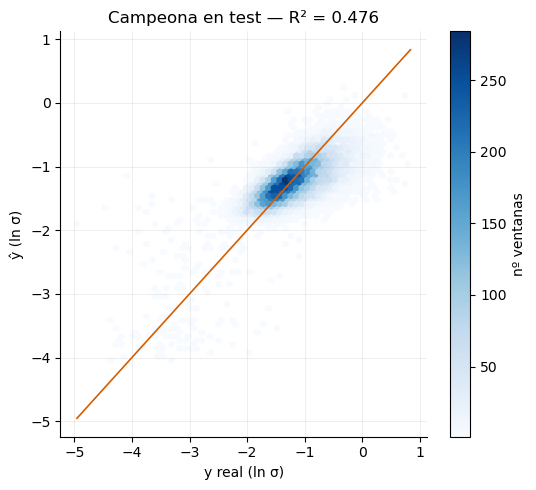

In [9]:
# Diagnóstico visual de la campeona en test: predicción vs realidad
p_test = predict(champion_model, Xs["test"], device) * std["y_sd"] + std["y_mu"]
fig, ax = plt.subplots(figsize=(5.5, 5))
hb = ax.hexbin(y["test"], p_test, gridsize=60, cmap="Blues", mincnt=1)
lims = [min(y["test"].min(), p_test.min()), max(y["test"].max(), p_test.max())]
ax.plot(lims, lims, color=PALETTE["vermillion"], lw=1.2)
ax.set_xlabel("y real (ln σ)"), ax.set_ylabel("ŷ (ln σ)")
ax.set_title(f"Campeona en test — R² = {regression_metrics(y['test'], p_test)['r2']:.3f}")
fig.colorbar(hb, ax=ax, label="nº ventanas")
_style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "10_pred_vs_real.png", dpi=120, bbox_inches="tight")

## 5 · Ficha visual de las arquitecturas

Las tablas de arriba dicen qué red gana; no dicen qué **forma** tiene. Esta sección
dibuja las seis candidatas con
[PlotNeuralNet](https://github.com/HarisIqbal88/PlotNeuralNet), la librería TikZ que
produce el diagrama isométrico habitual en los papers.

**Las recurrentes también.** Una GRU no tiene una pila de bloques que se encoge, así que
el walker de `src/netviz.py` la dibuja por lo que de verdad la distingue: una caja por
capa recurrente —apilar dos o tres GRU es una decisión de arquitectura y tiene que
verse— con la forma `(H, 60)` en todas. Comparar la ficha de `cnn_l` con la de `gru_l`
enseña el contraste de un vistazo: la CNN reduce la secuencia 60 → 30 → 15 → 7 mientras
engorda los canales, y la GRU la mantiene entera en 60 hasta el final. El colapso a un
vector lleva caja propia porque es donde la secuencia deja de serlo, y es el análogo
exacto del global average pooling de la CNN: mismo papel, distinto criterio —el último
estado en vez de la media sobre el tiempo.

**Los diagramas se derivan por introspección de los `nn.Module` reales**, no se dibujan
a mano. `src/netviz.py` recorre el modelo que devuelve `build_model(...)` y calcula
cada cifra con la aritmética de verdad de la convolución y el pooling: la cadena
60 → 30 → 15 → 7 de la CNN grande no está escrita en ninguna parte, sale de recorrer
las capas. Es una exigencia del diseño experimental, no una comodidad: en un notebook
cuyo contrato es *"la arquitectura queda congelada y a partir de aquí solo cambian los
datos"*, una figura capaz de desviarse en silencio del código sería una mentira
documental. Por la misma razón, el sello **CONGELADA** no está cableado en ningún
sitio: se decide comparando cada candidata contra `downstream_reference.json`, así que
si algún día cambia la campeona, el sello se mueve solo.

La compilación necesita LaTeX (`pdflatex` + `pdftoppm`). Es una dependencia **opcional**:
los `.png` y los `.tex` van versionados, y si falta LaTeX la celda avisa y muestra las
figuras cacheadas en lugar de fallar.

  + 16_arq_mlp_s: 23 KB


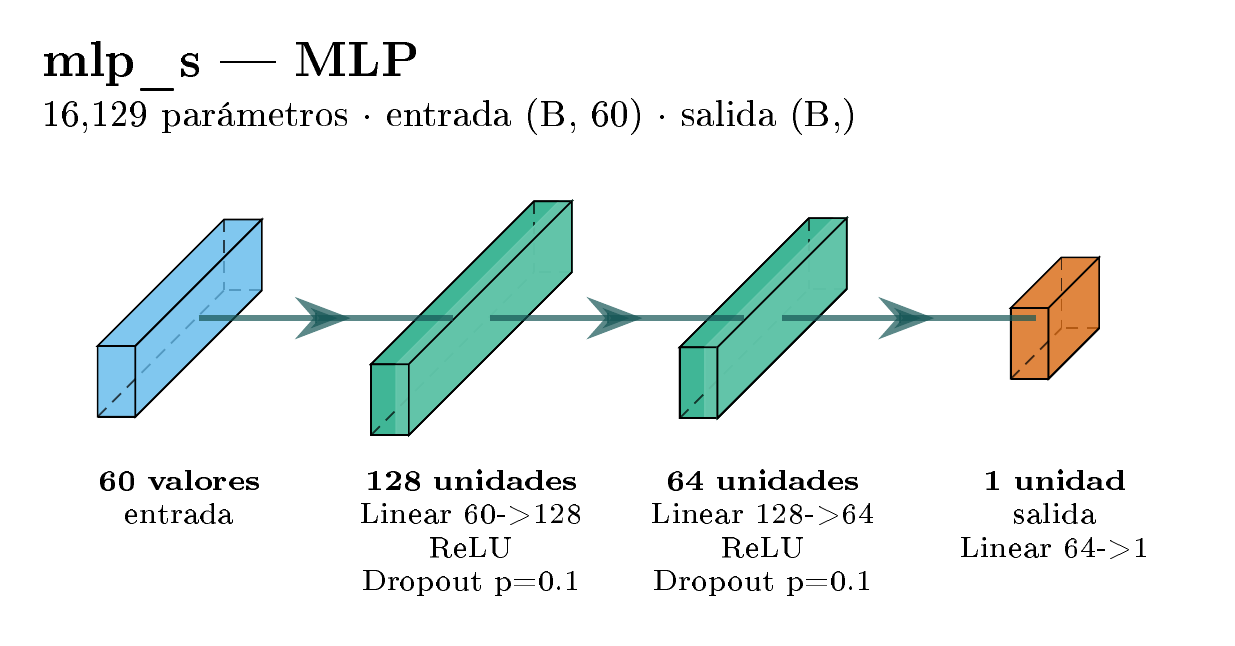

  + 17_arq_mlp_l: 31 KB


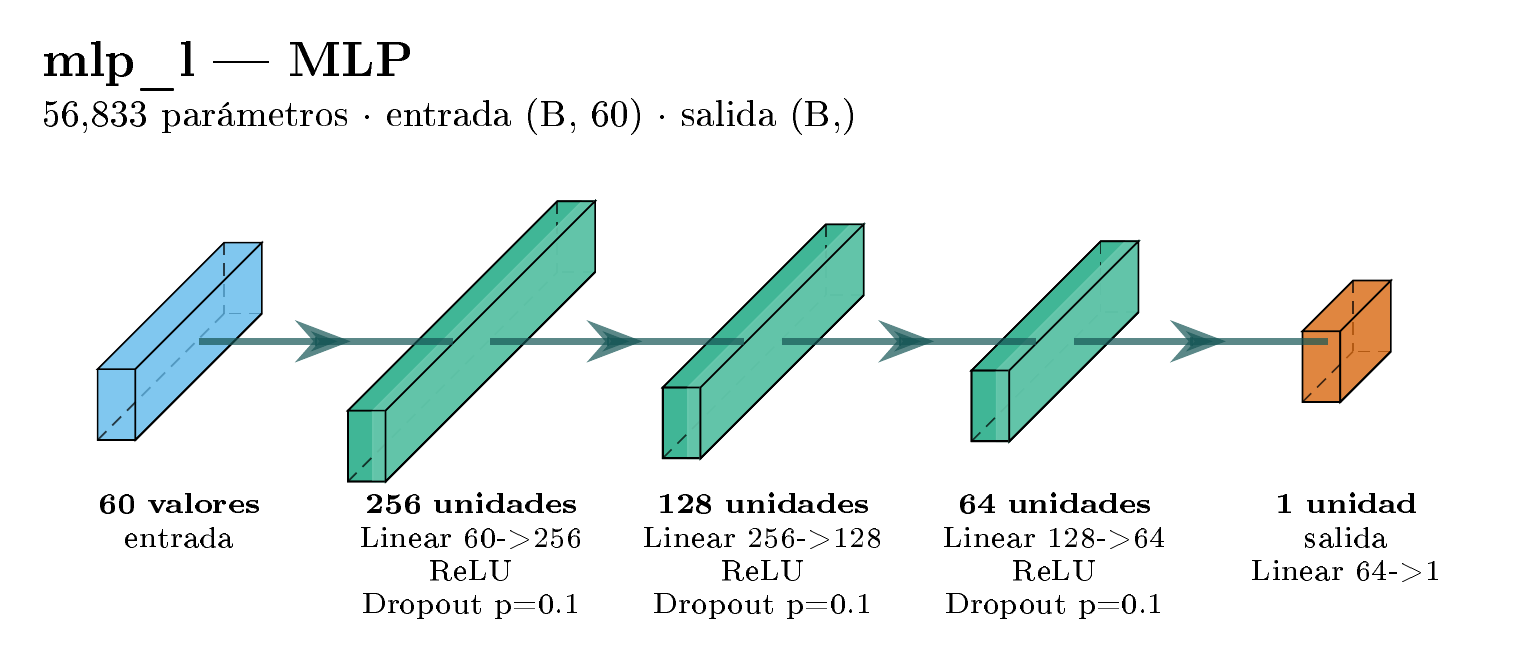

  + 18_arq_cnn_s: 43 KB


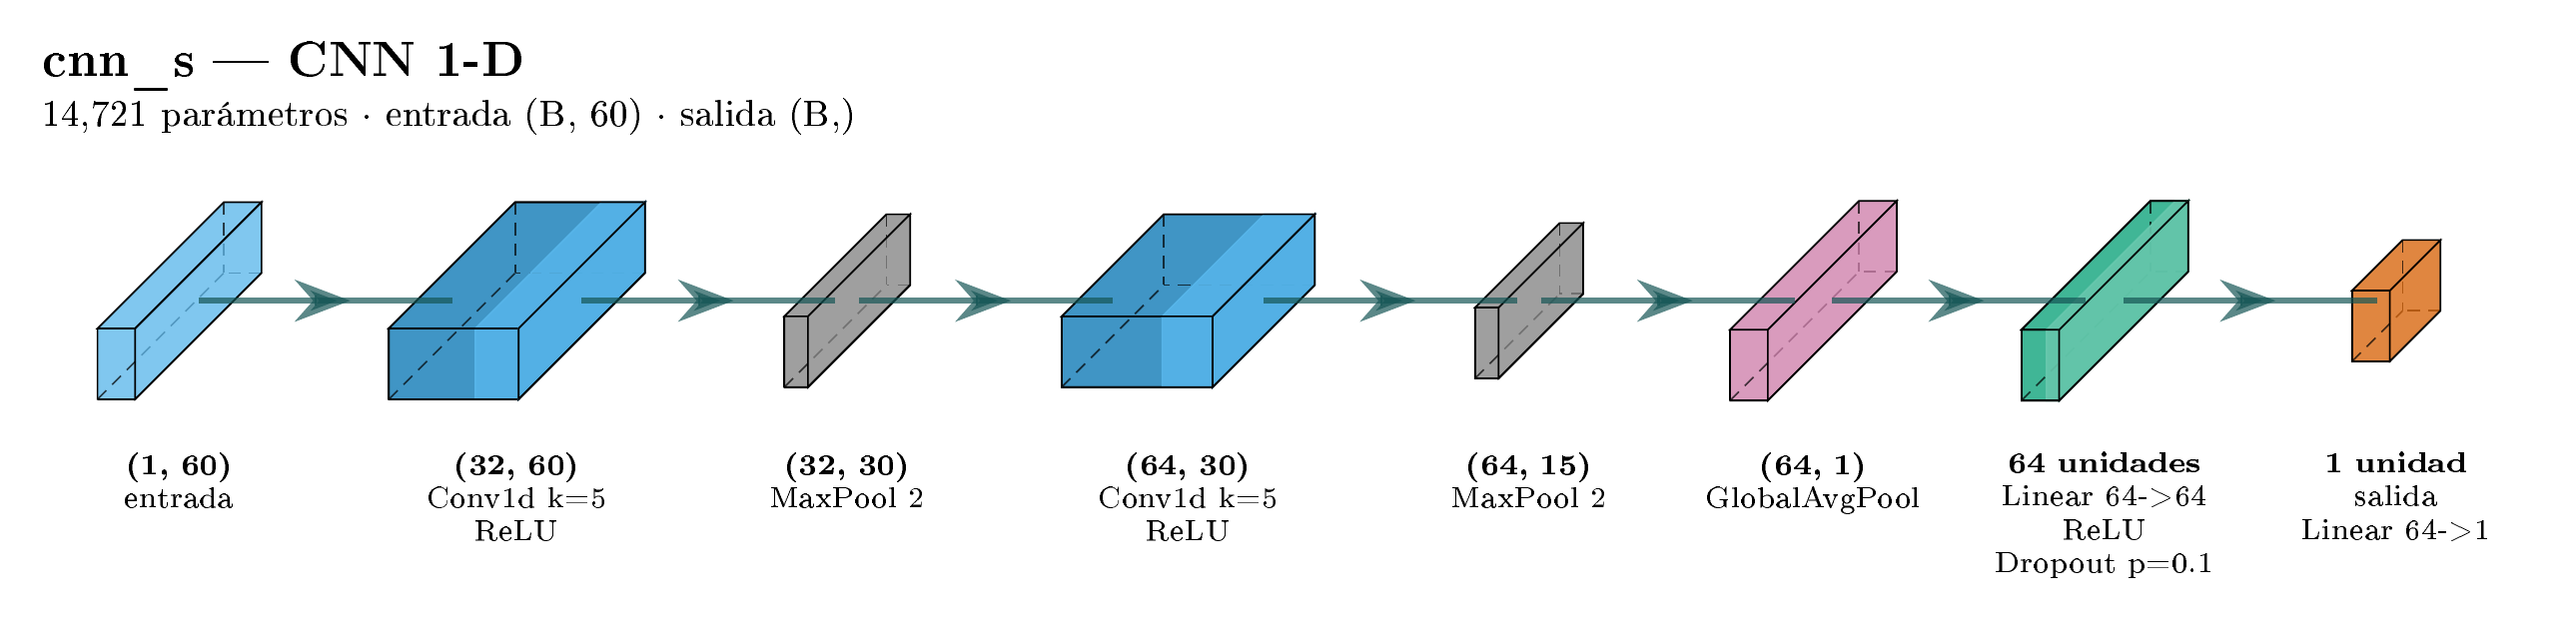

  + 19_arq_cnn_l: 51 KB


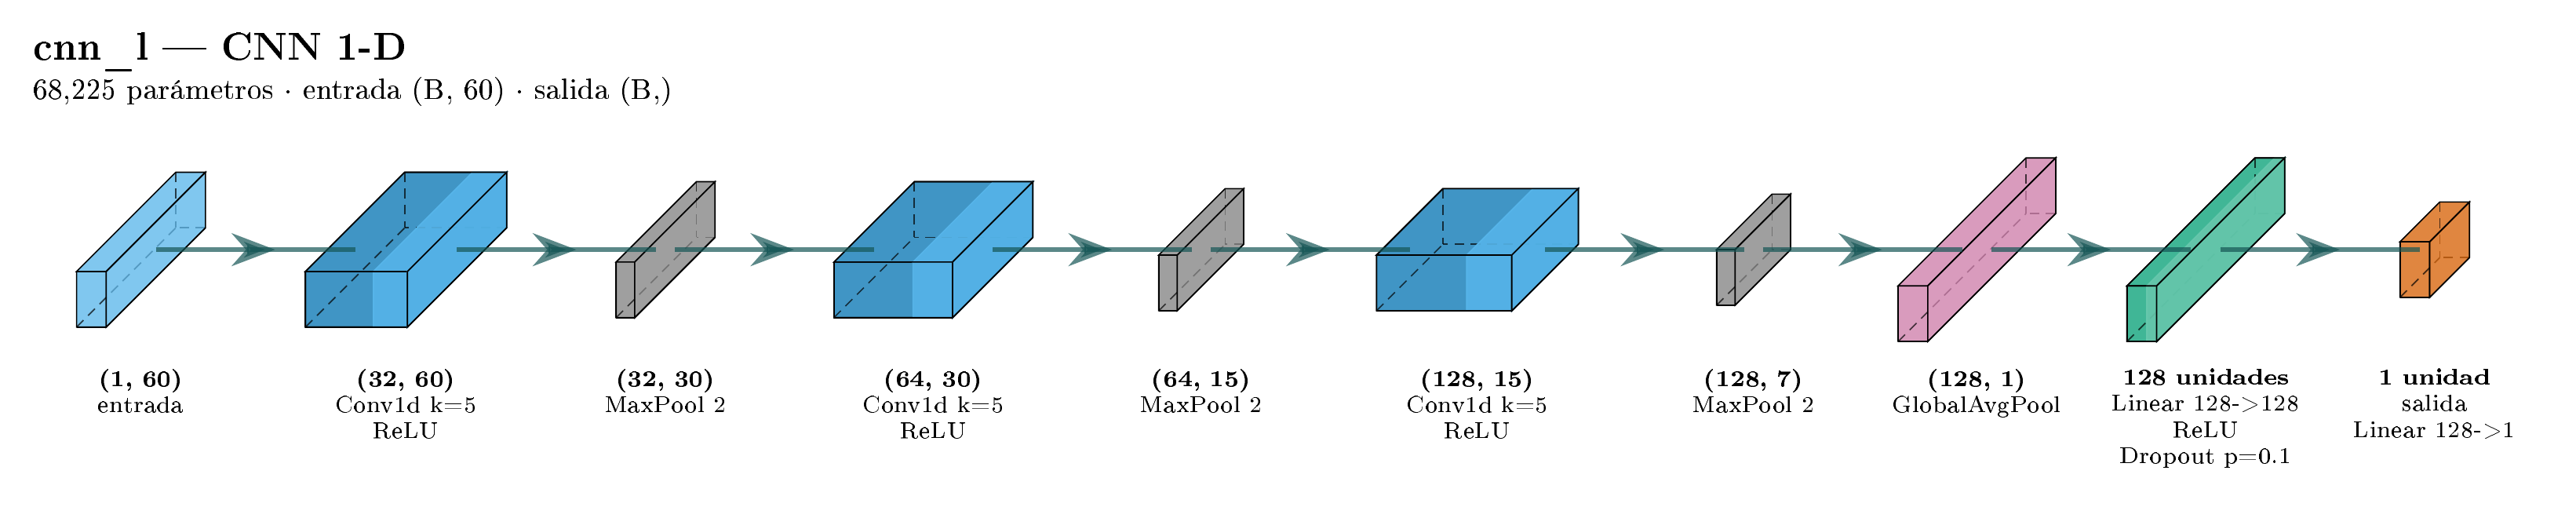

  = 29_arq_gru_s: sin cambios, se reutiliza el PNG cacheado


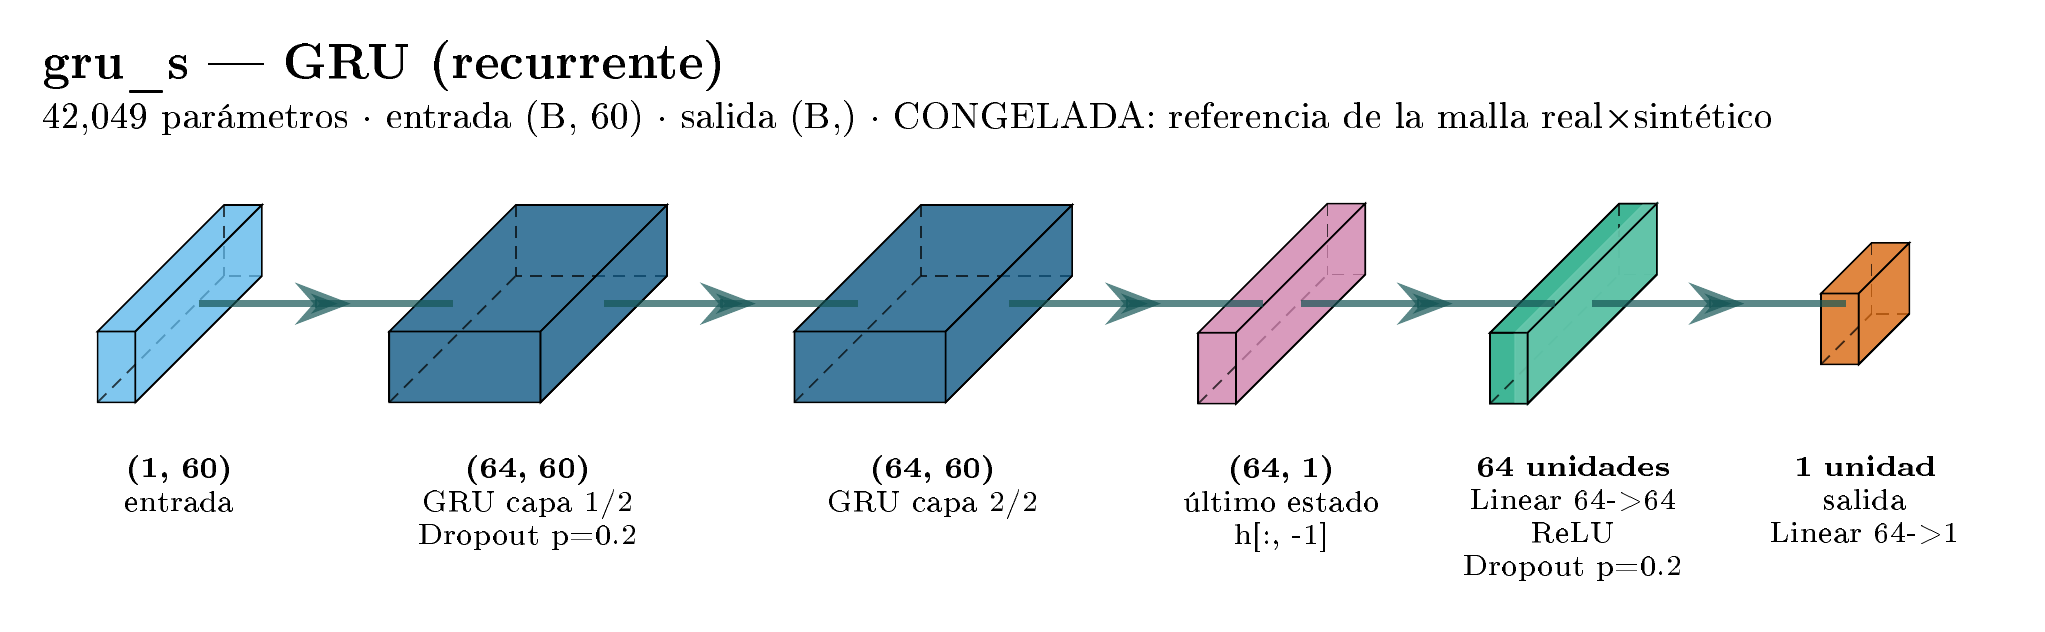

  = 30_arq_gru_l: sin cambios, se reutiliza el PNG cacheado


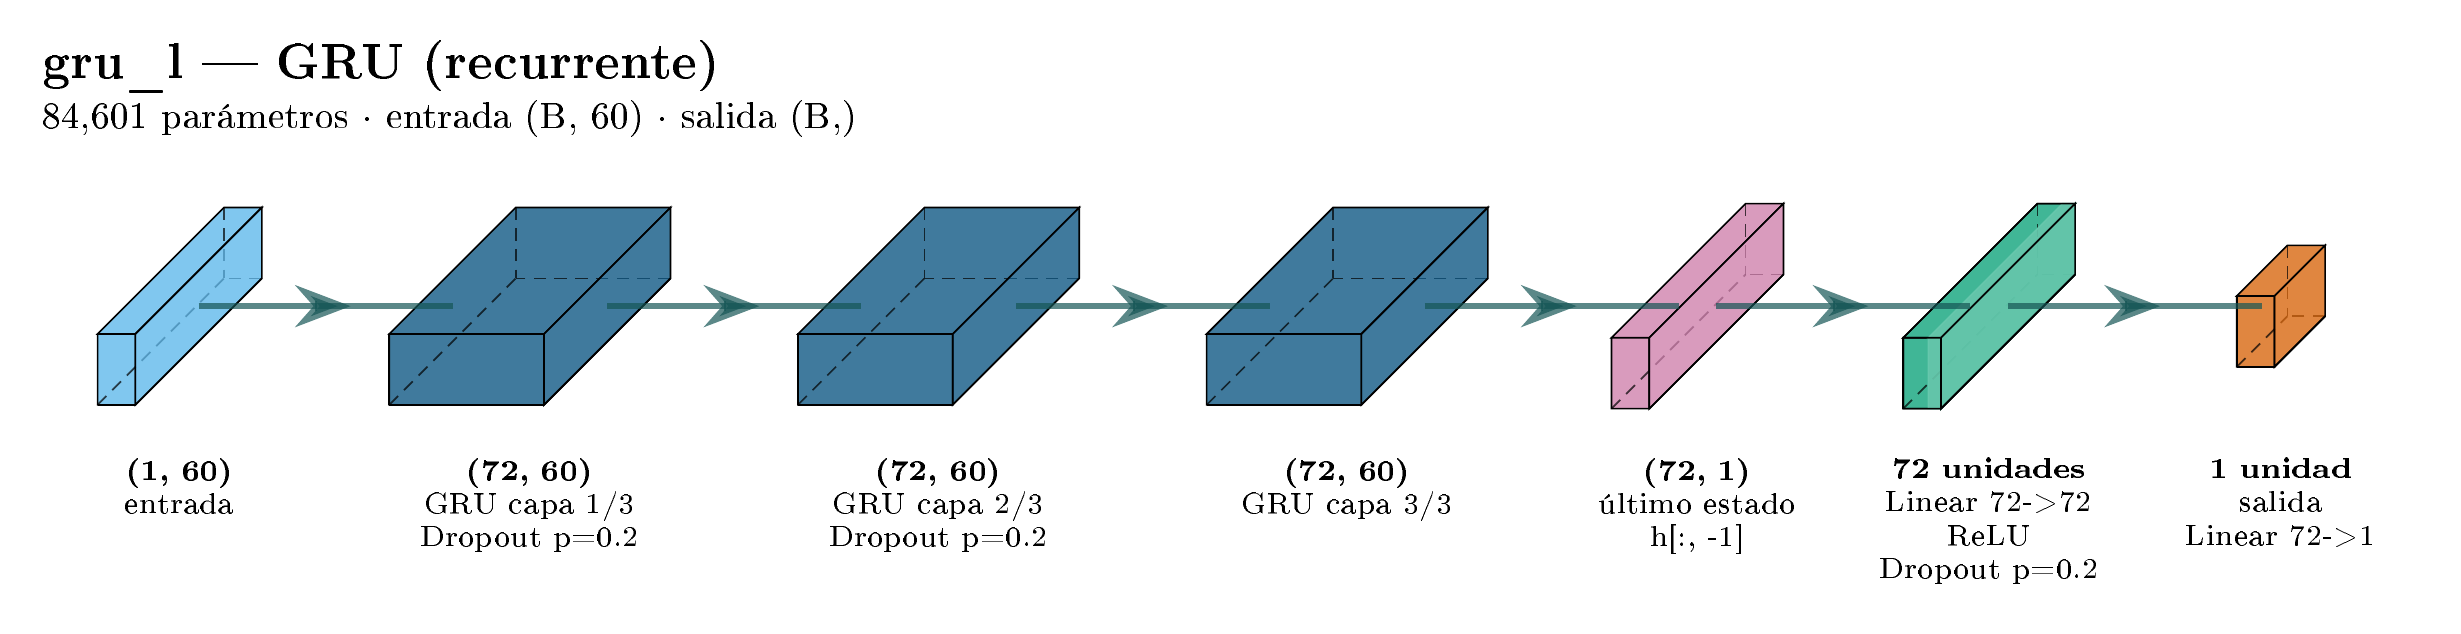

  + 23_pipeline_datos: 70 KB


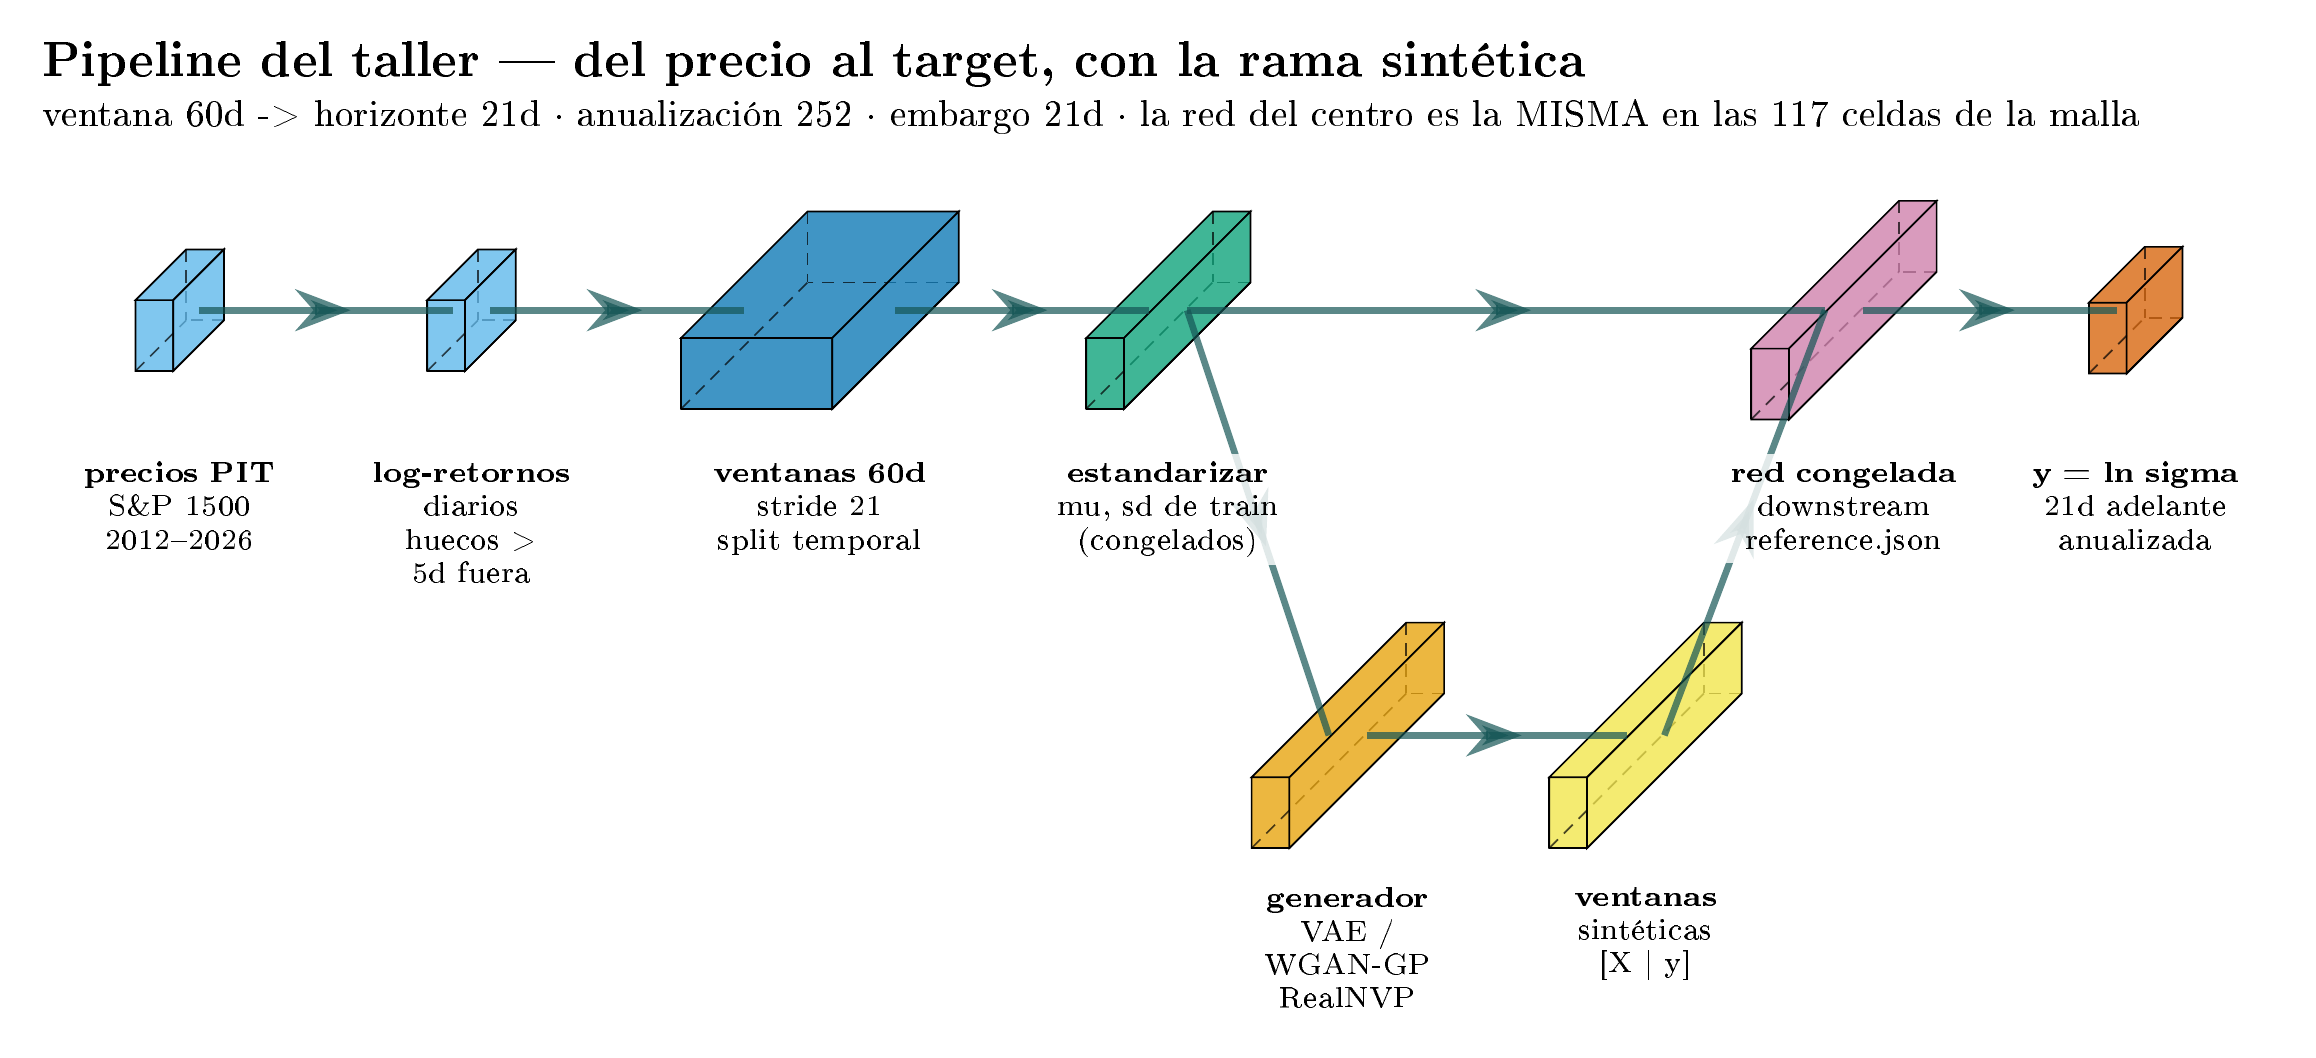

In [10]:
from IPython.display import Image, display

from src.netviz import diagramas_taller, render

# diagramas_taller() devuelve las 10 fichas del taller; aquí interesan las seis
# candidatas y el pipeline de datos (23). Los tres generadores (20-22) se dibujan
# en el notebook 03, junto al código que los entrena.
# Las dos GRU son 29 y 30, y no 20-21, porque esos números ya estaban ocupados
# cuando se añadieron: renumerar la carpeta entera es un cambio aparte.
DIAGRAMAS_02 = {"16", "17", "18", "19", "29", "30", "23"}

for diag in diagramas_taller(cfg):
    if diag.nombre[:2] not in DIAGRAMAS_02:
        continue
    png = render(diag, fig_dir=cfg.fig_dir)   # compila solo si el .tex cambió
    if png is not None:
        display(Image(filename=str(png), width=1000))

## 6 · Análisis crítico y contrato para los notebooks siguientes

**Lo que queda fijado** (nada de esto se vuelve a tocar):

* Arquitectura campeona + hiperparámetros de entrenamiento → `downstream_reference.json`
  (la malla la reconstruirá con `build_model(ref["arch"], **ref["arch_kwargs"])`).
* Métricas de referencia con 3 semillas: la dispersión entre semillas define el umbral de
  relevancia para cualquier efecto de los datos sintéticos.
* El suelo: HAR-RV. En la malla, cada mezcla real+sintético se comparará contra la red
  entrenada solo con reales *y* contra HAR con los mismos reales.
* La ficha visual de la sección 5, regenerable con
  `python scripts/make_arch_figures.py`. Al derivarse del propio modelo, cualquier
  cambio futuro en `src/models.py` se reflejaría en la figura — o dicho al revés: la
  figura no puede quedarse desfasada sin que nadie se entere.

**Lo que este notebook enseña, en frío:**

1. La ventaja de la mejor red sobre HAR existe pero es acotada — coherente con la
   literatura de RV forecasting. Esa distancia acota también el techo de lo que los datos
   sintéticos pueden aportar en el régimen de datos abundantes: poco. **La hipótesis del
   taller es que su valor aparecerá en el régimen de escasez** (pocas ventanas reales),
   que es exactamente lo que barrerá la malla del notebook 04.
2. La regresión hacia la media es visible en el hexbin: el modelo comprime los extremos
   (sobreestima σ baja, subestima σ alta). Típico de MSE + colas; relevante porque los
   generadores que no reproduzcan colas tenderán a agravarlo.
3. El tiempo por entrenamiento medido aquí dimensiona la malla del 04: con la campeona
   congelada, cientos de entrenamientos son viables en la RTX 5070 (y asumibles en CPU).
4. El diagrama de la campeona deja ver de un vistazo por qué es barata: el global average
   pooling colapsa la longitud a 1 antes de la cabeza densa, así que los 68k parámetros
   están casi todos en las convoluciones y no en un `Flatten` de 128×7.

**Siguiente notebook (03):** los generadores — baselines simples (jitter, gaussiana
multivariante, block bootstrap) y las tres familias neuronales (CVAE, WGAN-GP, flow),
entrenados exclusivamente con las ventanas reales de train y auditados contra los hechos
estilizados del notebook 01.